<div align="center">
<h1>Assignment 2: Build Regression Models</h1><br>
</div>

## 1. Import necessary libraries

In [18]:
import sys
sys.path.append('.')
from main import *

## 2. Dataset Overview

The training and test datasets are loaded from CSV files for further analysis.

In [19]:
ds_train = pd.read_csv('./data/train.csv')
ds_test = pd.read_csv('./data/test.csv')

The following displays the first few rows of the training dataset.

In [20]:
ds_train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


Below is a summary statistics for the training dataset

In [21]:
ds_train.describe().round(2)

,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.00,90615.00,90615.00,90615.00,90615.00,90615.00,90615.00,90615.00,90615.00
mean,45307.00,0.52,0.40,0.14,0.79,0.34,0.17,0.23,9.70
std,26158.44,0.12,0.10,0.04,0.46,0.20,0.10,0.13,3.18
min,0.00,0.08,0.06,0.00,0.00,0.00,0.00,0.00,1.00
25%,22653.50,0.44,0.34,0.11,0.42,0.18,0.09,0.12,8.00
50%,45307.00,0.55,0.42,0.14,0.80,0.33,0.17,0.22,9.00
75%,67960.50,0.60,0.47,0.16,1.07,0.46,0.23,0.30,11.00
max,90614.00,0.82,0.65,1.13,2.83,1.49,0.76,1.00,29.00


The following displays the dimensions (rows and columns) of the training and test datasets.

In [22]:
ds_train.shape, ds_test.shape

((90615, 10), (60411, 9))

To prepare for model evaluation, the training dataset is split into training and validation sets. The validation set is **8.333%** of the original training data, which is approximately **5%** of the full dataset (including both training and test data).

In [23]:
# Split raw train dataset into train and validation sets by stratifying on the Sex column (index 1)
X_train, X_validate, y_train, y_validate = tts(
    ds_train.iloc[:, 0:9],
    ds_train.iloc[:, 9],
    test_size=0.08333,  # ~5% of the original training and testing datasets
    random_state=42,
    stratify=ds_train.iloc[:, 1],  # Stratify on 'Sex' column
)

## 3. Exploratory Data Analysis

The correlation matrix provides insight into the relationships between numerical features in the training dataset. This information helps guide the selection of features to build regression models.

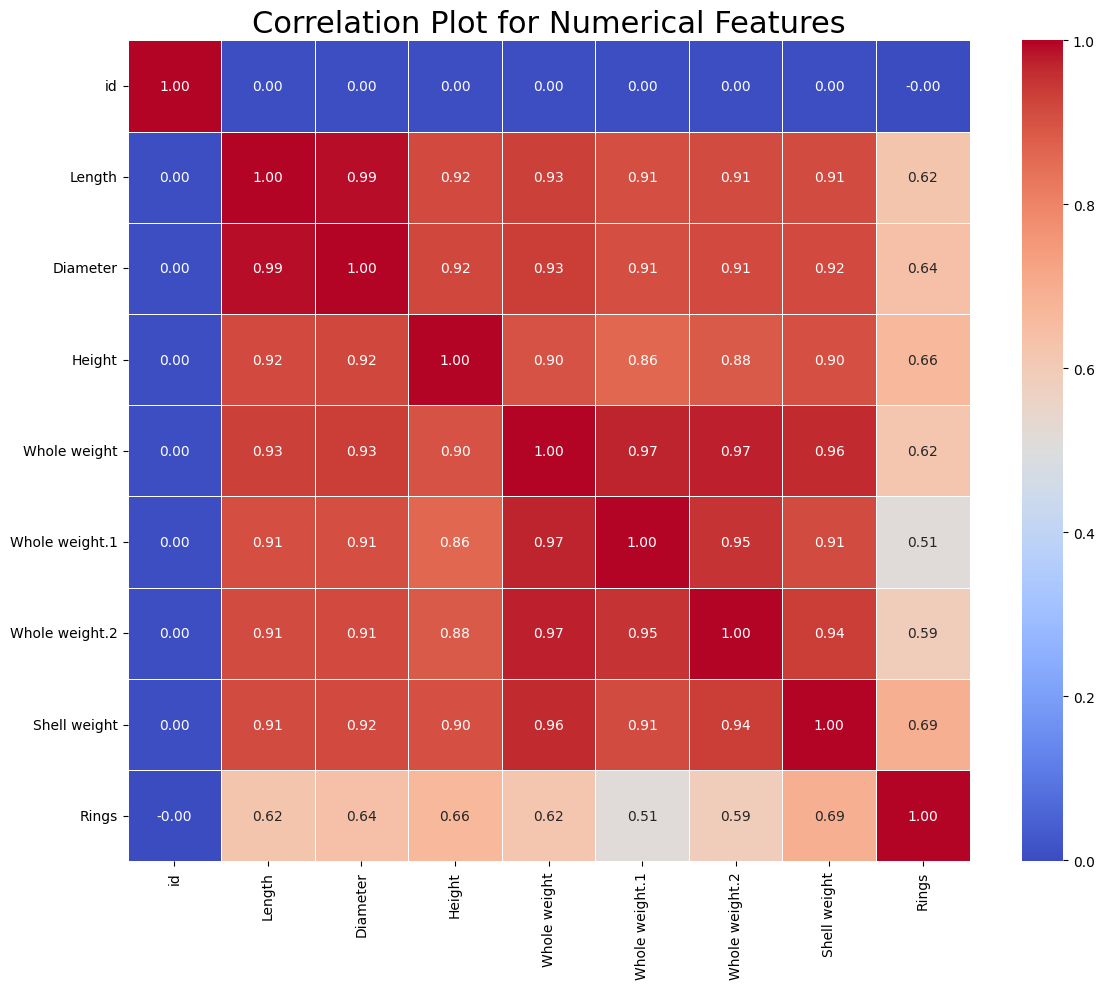

In [24]:
df_train = X_train.copy()
df_train['Rings'] = y_train
    
# Compute the correlation matrix for the numerical features in the training dataset
correlation_matrix = df_train.select_dtypes(include='number').corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap=color_palette("coolwarm", as_cmap=True), fmt=".2f", linewidths=0.5)
plt.title('Correlation Plot for Numerical Features', fontsize=22) 
plt.tight_layout() 
plt.show()

The following models are evaluated and assessed using the validation dataset.

Each model's performance is evaluated using the metrics: ME, MPE, MAE, MAPE, and MSE.

### Model 1: Linear Regression using Shell weight

In [25]:
model1 = LinearRegression()
model1.fit(X_train[['Shell weight']], y_train)
model1_y_pred = model1.predict(X_validate[['Shell weight']])
regression_metrics(y_validate, model1_y_pred)

ME,MPE,MAE,MAPE,MSE
0.01,-0.049,1.605,0.164,5.363


### Model 2: Linear Regression using Shell weight and Height

In [26]:
model2 = LinearRegression()
model2.fit(X_train[['Shell weight', 'Height']], y_train)
model2_y_pred = model2.predict(X_validate[['Shell weight', 'Height']])
regression_metrics(y_validate, model2_y_pred)

ME,MPE,MAE,MAPE,MSE
0.015,-0.046,1.586,0.16,5.26


### Model 3: Linear Regression using Shell weight and Diameter

In [27]:
model3 = LinearRegression()
model3.fit(X_train[['Shell weight', 'Diameter']], y_train)
model3_y_pred = model3.predict(X_validate[['Shell weight', 'Diameter']])
regression_metrics(y_validate, model3_y_pred)

ME,MPE,MAE,MAPE,MSE
0.01,-0.049,1.605,0.164,5.363


### Model 4: Linear Regression using Height and Diameter

In [28]:
model4 = LinearRegression()
model4.fit(X_train[['Height', 'Diameter']], y_train)
model4_y_pred = model4.predict(X_validate[['Height', 'Diameter']])
regression_metrics(y_validate, model4_y_pred)

ME,MPE,MAE,MAPE,MSE
0.024,-0.045,1.646,0.163,5.64


### Model 5: Linear Regression using Shell weight, Height, and Diameter

In [29]:
model5 = LinearRegression()
model5.fit(X_train[['Shell weight', 'Height', 'Diameter']], y_train)
model5_y_pred = model5.predict(X_validate[['Shell weight', 'Height', 'Diameter']])
regression_metrics(y_validate, model5_y_pred)

ME,MPE,MAE,MAPE,MSE
0.015,-0.047,1.579,0.161,5.206


### Model 6: Linear Regression using all features except Sex

In [30]:
model6 = LinearRegression()
model6.fit(X_train.drop(columns=["Sex"]), y_train)
model6_y_pred = model6.predict(X_validate.drop(columns=["Sex"]))
regression_metrics(y_validate, model6_y_pred)

ME,MPE,MAE,MAPE,MSE
0.011,-0.037,1.396,0.142,4.112


### Model 7: Linear Regression using all features, especially including Sex

In [31]:
# Encode 'Sex' column using one-hot encoding
X_train_encoded7 = pd.get_dummies(X_train, columns=["Sex"])
X_validate_encoded7 = pd.get_dummies(X_validate, columns=["Sex"])

# Ensure columns match between train and validate sets
X_validate_encoded7 = X_validate_encoded7.reindex(columns=X_train_encoded7.columns, fill_value=0)

model7 = LinearRegression()
model7.fit(X_train_encoded7, y_train)
model7_y_pred = model7.predict(X_validate_encoded7)
regression_metrics(y_validate, model7_y_pred)

ME,MPE,MAE,MAPE,MSE
0.01,-0.036,1.382,0.141,4.036


### Model 8: Linear Regression using Shell weight and Sex

In [32]:
# Encode 'Sex' column using one-hot encoding
X_train_encoded8 = pd.get_dummies(X_train[['Shell weight', 'Sex']], columns=["Sex"])
X_validate_encoded8 = pd.get_dummies(X_validate[['Shell weight', 'Sex']], columns=["Sex"])

# Ensure columns match between train and validate sets
X_validate_encoded8 = X_validate_encoded8.reindex(columns=X_train_encoded8.columns, fill_value=0)

model8 = LinearRegression()
model8.fit(X_train_encoded8, y_train)
model8_y_pred = model8.predict(X_validate_encoded8)
regression_metrics(y_validate, model8_y_pred)

ME,MPE,MAE,MAPE,MSE
0.01,-0.047,1.595,0.163,5.27


## 5. Select best models for Kaggle Submission

Two models were selected after comparison primarily using **MAE**, secondarily using **MSE**, and **MAPE** as third metric.

After selecting a model based on validation performance, retrain it using the **entire raw training dataset** (ds_train). This leverages all available data to improve accuracy before generating final predictions for the test set.

The prediction results are saved to CSV files and submitted to Kaggle for scoring.

### Selected Model 1: Linear Regression with Shell Weight

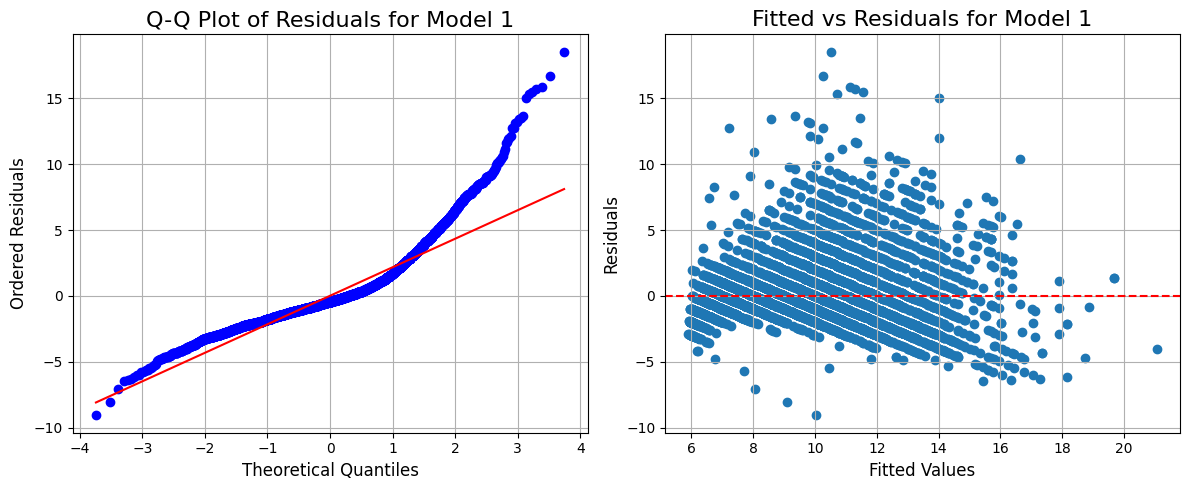

In [33]:
# Implement Q-Q and scatter plots for model 1 predictions on the validation set.
plot_regression_diagnostics(y_validate, model1_y_pred, model_name="Model 1")

Retrain the model 1 on the entire training dataset (train + validate) for final predictions on the test dataset

In [34]:
model1_selected = LinearRegression()
model1_selected.fit(ds_train[["Shell weight"]], ds_train["Rings"])
generate_predictions_and_save(
    model1_selected, ds_test, ["Shell weight"], "model1_test_predictions.csv"
)

### Selected Model 2: Linear Regression using all features
All features, including the categorical feature 'Sex', are used.

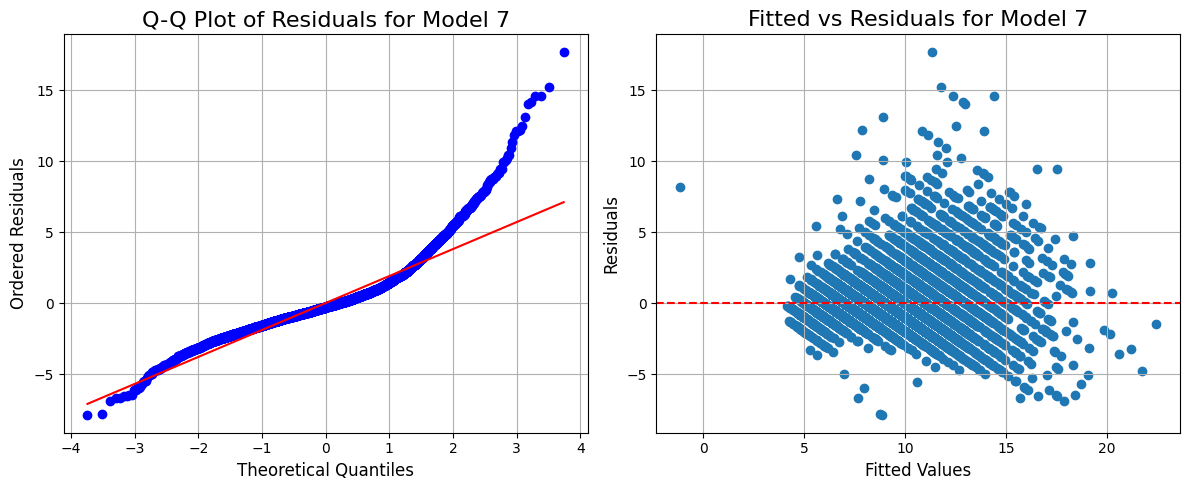

In [35]:
# Implement Q-Q plot for model 7 predictions on the validation set
plot_regression_diagnostics(y_validate, model7_y_pred, model_name="Model 7")

Retrain the model on the entire training dataset (train + validate) for final predictions on the test dataset

In [36]:
# Encode 'Sex' column in the entire training dataset using one-hot encoding
X_ds_train_encoded = pd.get_dummies(ds_train.drop(columns=["Rings"]), columns=["Sex"])
# Encode 'Sex' column in the test dataset using one-hot encoding
X_test_encoded = pd.get_dummies(ds_test.drop(columns=["Sex"]))
# Ensure columns match between train and test sets
X_test_encoded = X_test_encoded.reindex(
    columns=X_ds_train_encoded.columns, fill_value=0
)

model2_selected = LinearRegression()
model2_selected.fit(X_ds_train_encoded, ds_train["Rings"])
generate_predictions_and_save(
    model2_selected,
    X_test_encoded,
    X_test_encoded.columns,
    "model2_test_predictions.csv",
)

<style>
.celltag_hide_input {
    display: none !important;
}
</style>